In [1]:
import os
import random
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import seaborn as sns

Dataset

In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    if len(files) > 0:
        print("Files:", files[:5])

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/priyal1608
/kaggle/input/datasets/priyal1608/trashimg
Files: ['Trash2.png', 'Trash4.jpeg', 'Trash.jpeg', 'Trash3.webp']
/kaggle/input/datasets/feyzazkefe
/kaggle/input/datasets/feyzazkefe/trashnet
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/metal
Files: ['metal375.jpg', 'metal341.jpg', 'metal374.jpg', 'metal383.jpg', 'metal215.jpg']
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/glass
Files: ['glass141.jpg', 'glass374.jpg', 'glass184.jpg', 'glass75.jpg', 'glass409.jpg']
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/paper
Files: ['paper508.jpg', 'paper20.jpg', 'paper574.jpg', 'paper213.jpg', 'paper14.jpg']
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/trash
Files: ['trash79.jpg', 'trash84.jpg', 'trash55.jpg', 'trash109.jpg', 'trash90.jpg']
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/cardboard
Files: ['c

In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input"):

    # Check whether this folder contains the TrashNet classes
    required_classes = {
        "cardboard",
        "glass",
        "metal",
        "paper",
        "plastic",
        "trash"
    }

    if required_classes.issubset(set(dirs)):
        print("FOUND TRASHNET DATASET:")
        print(root)

FOUND TRASHNET DATASET:
/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized


In [4]:
import os

DATA_DIR = "/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized"

print(os.listdir(DATA_DIR))


['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']


In [5]:
for class_name in sorted(os.listdir(DATA_DIR)):

    class_path = os.path.join(DATA_DIR, class_name)

    if os.path.isdir(class_path):

        images = os.listdir(class_path)

        print(f"{class_name}: {len(images)} images")

cardboard: 403 images
glass: 501 images
metal: 410 images
paper: 594 images
plastic: 482 images
trash: 137 images


In [6]:
from torchvision import datasets

dataset = datasets.ImageFolder(
    root=DATA_DIR
)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)

Total images: 2527
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Class mapping: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


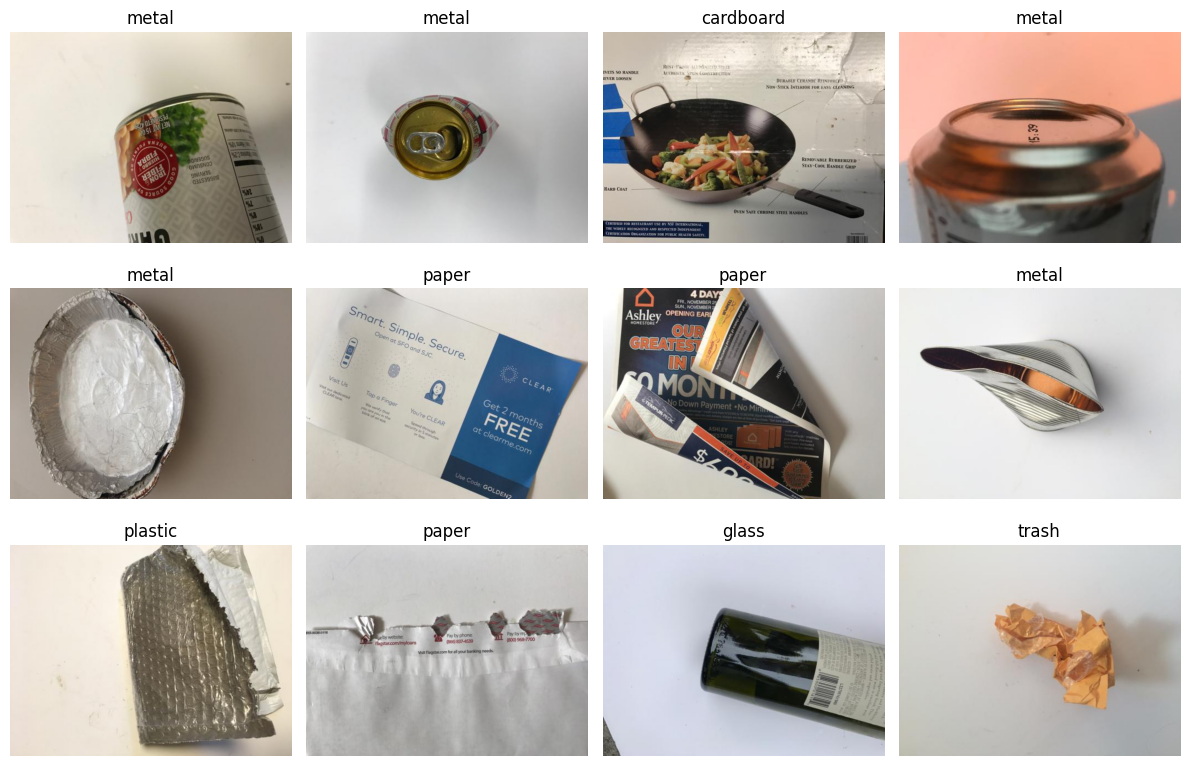

In [7]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(12, 8))

for i in range(12):

    index = random.randint(0, len(dataset) - 1)

    image, label = dataset[index]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(dataset.classes[label])

    plt.axis("off")

plt.tight_layout()
plt.show()


In [8]:
from torch.utils.data import random_split

total_size = len(dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset, test_subset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Test images:", len(test_subset))

Training images: 1768
Validation images: 379
Test images: 380


In [9]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
train_dataset_full = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)

eval_dataset_full = datasets.ImageFolder(
    root=DATA_DIR,
    transform=val_test_transform
)

In [12]:
train_dataset = torch.utils.data.Subset(
    train_dataset_full,
    train_subset.indices
)

val_dataset = torch.utils.data.Subset(
    eval_dataset_full,
    val_subset.indices
)

test_dataset = torch.utils.data.Subset(
    eval_dataset_full,
    test_subset.indices
)

Dataprocessing

In [13]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

DATA_DIR = "/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized" 

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

base_dataset = datasets.ImageFolder(
    root=DATA_DIR
)

print("Classes:", base_dataset.classes)
print("Total images:", len(base_dataset))

total_size = len(base_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset, test_subset = random_split(
    base_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("\nDataset split:")
print("Train:", len(train_subset))
print("Validation:", len(val_subset))
print("Test:", len(test_subset))

train_dataset_full = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)

eval_dataset_full = datasets.ImageFolder(
    root=DATA_DIR,
    transform=val_test_transform
)

train_dataset = torch.utils.data.Subset(
    train_dataset_full,
    train_subset.indices
)

val_dataset = torch.utils.data.Subset(
    eval_dataset_full,
    val_subset.indices
)

test_dataset = torch.utils.data.Subset(
    eval_dataset_full,
    test_subset.indices
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
images, labels = next(iter(train_loader))

print("\nBatch verification:")
print("Image shape:", images.shape)
print("Label shape:", labels.shape)

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Total images: 2527

Dataset split:
Train: 1768
Validation: 379
Test: 380

Device: cuda
GPU: Tesla T4

Batch verification:
Image shape: torch.Size([32, 3, 224, 224])
Label shape: torch.Size([32])


# Training Efficient-Net model Baseline model 

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

for param in model.features.parameters():
    param.requires_grad = False

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 6)
)

model = model.to(device)

print(model)

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 126MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Loss Function And Optimizer(AdamW)

In [15]:

criterion = nn.CrossEntropyLoss()


optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Optimizer:", optimizer)
print("Scheduler:", scheduler)

Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x781da905c5c0>


#  Train and Validate 

In [16]:


def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training")

    for images, labels in progress_bar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        progress_bar.set_postfix(
            loss=loss.item(),
            accuracy=100 * correct / total
        )

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        progress_bar = tqdm(loader, desc="Validation")

        for images, labels in progress_bar:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

# Training Baseline with 5 epoch

In [17]:


EPOCHS = 5

best_val_loss = float("inf")
best_model_path = "/kaggle/working/efficientnet_b0_baseline.pth"

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(EPOCHS):

    print("\n" + "=" * 60)
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("=" * 60)

    # Training
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Validation
    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # Scheduler
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(f"\nTrain Loss     : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc * 100:.2f}%")
    print(f"Val Loss       : {val_loss:.4f}")
    print(f"Val Accuracy   : {val_acc * 100:.2f}%")

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("✓ Best model saved")


print("\nTraining completed.")
print("Best model:", best_model_path)


Epoch 1/5


Training:   0%|          | 0/56 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]


Train Loss     : 1.2910
Train Accuracy : 57.41%
Val Loss       : 0.9889
Val Accuracy   : 71.24%
✓ Best model saved

Epoch 2/5


Training:   0%|          | 0/56 [00:00<?, ?it/s]

...

Training:   0%|          | 0/56 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x781dc7bae7a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x781dc7bae7a0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    ^
self._shutdown_workers()  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    assert self._parent_pid == os.getpid(), 'can only test a child process'if w.is_alive():

               ^ ^  ^^^^^^^^^^^^^^^^^^^^^^


Validation:   0%|          | 0/12 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x781dc7bae7a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x781dc7bae7a0>
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^self._shutdown_workers()
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^^ ^ ^ ^  ^^ 


Train Loss     : 0.6510
Train Accuracy : 78.05%
Val Loss       : 0.6251
Val Accuracy   : 79.68%
✓ Best model saved

Training completed.
Best model: /kaggle/working/efficientnet_b0_baseline.pth


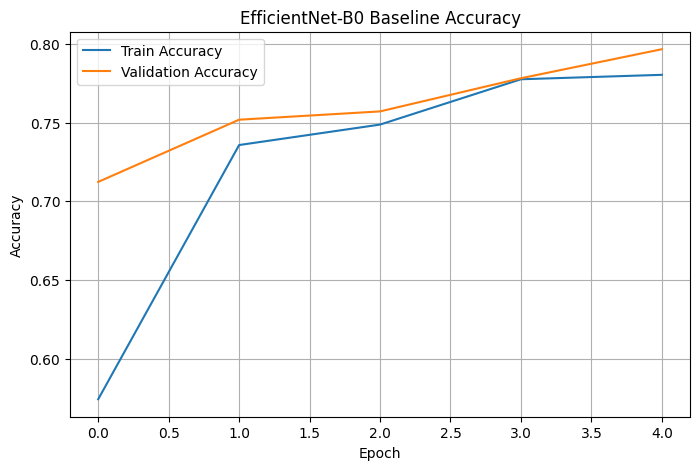

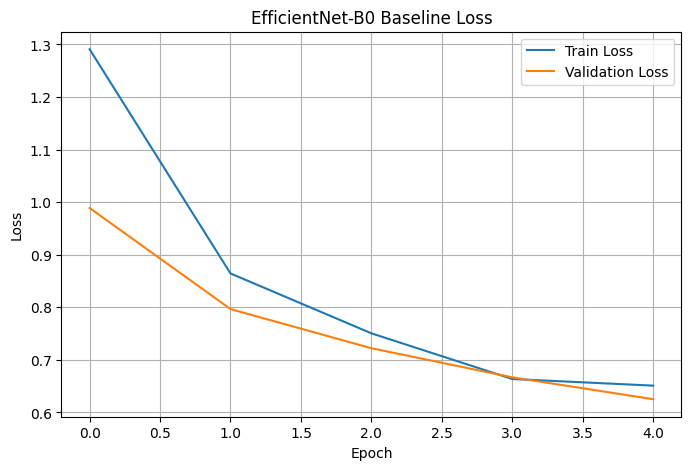

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B0 Baseline Accuracy")

plt.legend()
plt.grid(True)

plt.show()
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Baseline Loss")

plt.legend()
plt.grid(True)

plt.show()

# Test data Evalution

Test Accuracy : 80.53%
Macro F1      : 0.7518
Weighted F1   : 0.7979

Classification Report:

              precision    recall  f1-score   support

   cardboard     0.9298    0.8983    0.9138        59
       glass     0.8354    0.8462    0.8408        78
       metal     0.6707    0.9016    0.7692        61
       paper     0.8723    0.8913    0.8817        92
     plastic     0.7414    0.6515    0.6935        66
       trash     0.7000    0.2917    0.4118        24

    accuracy                         0.8053       380
   macro avg     0.7916    0.7468    0.7518       380
weighted avg     0.8077    0.8053    0.7979       380



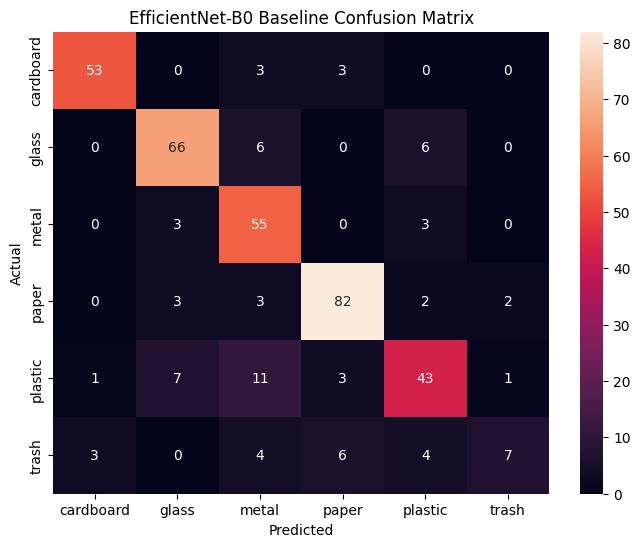

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

model.load_state_dict(
    torch.load(
        "/kaggle/working/efficientnet_b0_baseline.pth",
        map_location=device
    )
)

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

accuracy = accuracy_score(all_labels, all_predictions)
macro_f1 = f1_score(all_labels, all_predictions, average="macro")
weighted_f1 = f1_score(all_labels, all_predictions, average="weighted")

print(f"Test Accuracy : {accuracy * 100:.2f}%")
print(f"Macro F1      : {macro_f1:.4f}")
print(f"Weighted F1   : {weighted_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=base_dataset.classes,
        digits=4
    )
)

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=base_dataset.classes,
    yticklabels=base_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNet-B0 Baseline Confusion Matrix")
plt.show()

# GWO Optimizer

In [20]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import gc
class GreyWolfOptimizer:

    def __init__(
        self,
        objective_function,
        bounds,
        num_wolves=5,
        max_iter=5
    ):
        self.objective_function = objective_function
        self.bounds = np.array(bounds, dtype=float)
        self.num_wolves = num_wolves
        self.max_iter = max_iter
        self.dim = len(bounds)

        self.positions = np.random.uniform(
            self.bounds[:, 0],
            self.bounds[:, 1],
            size=(num_wolves, self.dim)
        )

        self.alpha_position = None
        self.beta_position = None
        self.delta_position = None

        self.alpha_score = float("inf")
        self.beta_score = float("inf")
        self.delta_score = float("inf")

    def optimize(self):

        for iteration in range(self.max_iter):

            print(
                f"\nGWO Iteration {iteration + 1}/{self.max_iter}"
            )

            for i in range(self.num_wolves):

                self.positions[i] = np.clip(
                    self.positions[i],
                    self.bounds[:, 0],
                    self.bounds[:, 1]
                )

                score = self.objective_function(
                    self.positions[i]
                )

                print(
                    f"Wolf {i + 1}/{self.num_wolves} | "
                    f"Fitness: {score:.5f}"
                )

                if score < self.alpha_score:

                    self.delta_score = self.beta_score
                    self.delta_position = (
                        None if self.beta_position is None
                        else self.beta_position.copy()
                    )

                    self.beta_score = self.alpha_score
                    self.beta_position = (
                        None if self.alpha_position is None
                        else self.alpha_position.copy()
                    )

                    self.alpha_score = score
                    self.alpha_position = self.positions[i].copy()

                elif score < self.beta_score:

                    self.delta_score = self.beta_score
                    self.delta_position = (
                        None if self.beta_position is None
                        else self.beta_position.copy()
                    )

                    self.beta_score = score
                    self.beta_position = self.positions[i].copy()

                elif score < self.delta_score:

                    self.delta_score = score
                    self.delta_position = self.positions[i].copy()

            a = 2 - iteration * (2 / self.max_iter)

            for i in range(self.num_wolves):

                for j in range(self.dim):

                    r1 = np.random.random()
                    r2 = np.random.random()

                    A1 = 2 * a * r1 - a
                    C1 = 2 * r2

                    if self.alpha_position is not None:
                        D_alpha = abs(
                            C1 * self.alpha_position[j]
                            - self.positions[i, j]
                        )

                        X1 = (
                            self.alpha_position[j]
                            - A1 * D_alpha
                        )
                    else:
                        X1 = self.positions[i, j]

                    r1 = np.random.random()
                    r2 = np.random.random()

                    A2 = 2 * a * r1 - a
                    C2 = 2 * r2

                    if self.beta_position is not None:
                        D_beta = abs(
                            C2 * self.beta_position[j]
                            - self.positions[i, j]
                        )

                        X2 = (
                            self.beta_position[j]
                            - A2 * D_beta
                        )
                    else:
                        X2 = self.positions[i, j]

                    r1 = np.random.random()
                    r2 = np.random.random()

                    A3 = 2 * a * r1 - a
                    C3 = 2 * r2

                    if self.delta_position is not None:
                        D_delta = abs(
                            C3 * self.delta_position[j]
                            - self.positions[i, j]
                        )

                        X3 = (
                            self.delta_position[j]
                            - A3 * D_delta
                        )
                    else:
                        X3 = self.positions[i, j]

                    self.positions[i, j] = (
                        X1 + X2 + X3
                    ) / 3

            print(
                f"Best fitness: {self.alpha_score:.5f}"
            )

        return self.alpha_position, self.alpha_score

Hyper-Parameter Decoding

In [21]:
batch_options = [16, 32, 64]

def decode_parameters(position):

    learning_rate = float(position[0])
    dropout = float(position[1])
    weight_decay = float(position[2])

    batch_index = int(
        np.clip(
            round(position[3]),
            0,
            len(batch_options) - 1
        )
    )

    batch_size = batch_options[batch_index]

    return {
        "learning_rate": learning_rate,
        "dropout": dropout,
        "weight_decay": weight_decay,
        "batch_size": batch_size
    }


def create_model(dropout):

    weights = models.EfficientNet_B0_Weights.DEFAULT

    model = models.efficientnet_b0(
        weights=weights
    )

    for param in model.features.parameters():
        param.requires_grad = False

    num_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(num_features, 6)
    )

    return model.to(device)


def gwo_objective(position):

    params = decode_parameters(position)

    print("\nTesting:", params)

    trial_model = create_model(
        params["dropout"]
    )

    trial_train_loader = DataLoader(
        train_dataset,
        batch_size=params["batch_size"],
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    trial_val_loader = DataLoader(
        val_dataset,
        batch_size=params["batch_size"],
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    criterion_trial = nn.CrossEntropyLoss()

    optimizer_trial = optim.AdamW(
        trial_model.classifier.parameters(),
        lr=params["learning_rate"],
        weight_decay=params["weight_decay"]
    )

    proxy_epochs = 3

    best_val_loss = float("inf")

    for epoch in range(proxy_epochs):

        trial_model.train()

        running_loss = 0.0
        total = 0

        for images, labels in trial_train_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            optimizer_trial.zero_grad()

            outputs = trial_model(images)

            loss = criterion_trial(
                outputs,
                labels
            )

            loss.backward()

            optimizer_trial.step()

            running_loss += (
                loss.item() * images.size(0)
            )

            total += images.size(0)

        trial_model.eval()

        val_loss = 0.0
        val_total = 0

        with torch.no_grad():

            for images, labels in trial_val_loader:

                images = images.to(
                    device,
                    non_blocking=True
                )

                labels = labels.to(
                    device,
                    non_blocking=True
                )

                outputs = trial_model(images)

                loss = criterion_trial(
                    outputs,
                    labels
                )

                val_loss += (
                    loss.item() * images.size(0)
                )

                val_total += images.size(0)

        val_loss /= val_total

        best_val_loss = min(
            best_val_loss,
            val_loss
        )

        print(
            f"Epoch {epoch + 1}/{proxy_epochs} "
            f"| Val Loss: {val_loss:.5f}"
        )

    del trial_model
    del trial_train_loader
    del trial_val_loader
    del optimizer_trial

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_val_loss

In [22]:
bounds = [
    (1e-5, 1e-3),
    (0.1, 0.5),
    (1e-6, 1e-3),
    (0, 2)
]

gwo = GreyWolfOptimizer(
    objective_function=gwo_objective,
    bounds=bounds,
    num_wolves=5,
    max_iter=5
)

best_position, best_score = gwo.optimize()

best_params = decode_parameters(best_position)

print("\n" + "=" * 60)
print("GWO COMPLETE")
print("=" * 60)

print("Best validation loss:", best_score)
print("Best parameters:")

for key, value in best_params.items():
    print(f"{key}: {value}")


GWO Iteration 1/5

Testing: {'learning_rate': 2.7266963608185628e-05, 'dropout': 0.4964728525115387, 'weight_decay': 6.851693073310295e-05, 'batch_size': 16}
Epoch 1/3 | Val Loss: 1.74297
Epoch 2/3 | Val Loss: 1.69172
Epoch 3/3 | Val Loss: 1.64114
Wolf 1/5 | Fitness: 1.64114

Testing: {'learning_rate': 0.0004888836933856378, 'dropout': 0.23040706328560343, 'weight_decay': 0.00045944981079416814, 'batch_size': 32}
Epoch 1/3 | Val Loss: 1.22156
Epoch 2/3 | Val Loss: 0.98606
Epoch 3/3 | Val Loss: 0.86684
Wolf 2/5 | Fitness: 0.86684

Testing: {'learning_rate': 0.00019714814486979012, 'dropout': 0.2684586239074842, 'weight_decay': 7.85651630434614e-06, 'batch_size': 64}
Epoch 1/3 | Val Loss: 1.60032
Epoch 2/3 | Val Loss: 1.44995
Epoch 3/3 | Val Loss: 1.33464
Wolf 3/5 | Fitness: 1.33464

Testing: {'learning_rate': 0.0005130790894012052, 'dropout': 0.472309723746816, 'weight_decay': 0.0009769768869859346, 'batch_size': 32}
Epoch 1/3 | Val Loss: 1.27397
Epoch 2/3 | Val Loss: 1.05653
Epoch 3/3

# GWO + EfficientNet Model

In [23]:
final_model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

for param in final_model.features.parameters():
    param.requires_grad = False

for param in final_model.features[-3:].parameters():
    param.requires_grad = True

num_features = final_model.classifier[1].in_features

final_model.classifier = nn.Sequential(
    nn.Dropout(p=best_params["dropout"]),
    nn.Linear(num_features, 6)
)

final_model = final_model.to(device)

print("Final GWO-EfficientNet model ready")
print(best_params)

Final GWO-EfficientNet model ready
{'learning_rate': 0.000898318945842229, 'dropout': 0.16252642332941397, 'weight_decay': 0.00013769791298119116, 'batch_size': 16}


In [24]:
from torch.utils.data import DataLoader

gwo_train_loader = DataLoader(
    train_dataset,
    batch_size=best_params["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

gwo_val_loader = DataLoader(
    val_dataset,
    batch_size=best_params["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

gwo_test_loader = DataLoader(
    test_dataset,
    batch_size=best_params["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Optimizer + Sechduler

In [25]:
criterion = nn.CrossEntropyLoss()

backbone_params = []
classifier_params = []

for name, param in final_model.named_parameters():
    if param.requires_grad:
        if "classifier" in name:
            classifier_params.append(param)
        else:
            backbone_params.append(param)

optimizer = torch.optim.AdamW(
    [
        {
            "params": backbone_params,
            "lr": best_params["learning_rate"] * 0.1
        },
        {
            "params": classifier_params,
            "lr": best_params["learning_rate"]
        }
    ],
    weight_decay=best_params["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

**Train Final Model**

In [26]:
from tqdm.auto import tqdm

EPOCHS = 15

best_val_loss = float("inf")

final_model_path = "/kaggle/working/gwo_efficientnet_trashnet.pth"

history_gwo = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(EPOCHS):

    final_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    progress = tqdm(
        gwo_train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for images, labels in progress:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = final_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss /= train_total
    train_accuracy = train_correct / train_total

    final_model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in gwo_val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = final_model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss /= val_total
    val_accuracy = val_correct / val_total

    scheduler.step(val_loss)

    history_gwo["train_loss"].append(train_loss)
    history_gwo["train_accuracy"].append(train_accuracy)
    history_gwo["val_loss"].append(val_loss)
    history_gwo["val_accuracy"].append(val_accuracy)

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy * 100:.2f}%"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy * 100:.2f}%"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            final_model.state_dict(),
            final_model_path
        )

        print("Best GWO model saved")

Epoch 1/15:   0%|          | 0/111 [00:00<?, ?it/s]


Epoch 1/15
Train Loss: 1.0331 | Train Accuracy: 64.20%
Val Loss: 0.5930 | Val Accuracy: 79.42%
Best GWO model saved


Epoch 2/15:   0%|          | 0/111 [00:00<?, ?it/s]


Epoch 2/15
Train Loss: 0.5231 | Train Accuracy: 82.64%
Val Loss: 0.4403 | Val Accuracy: 82.85%
Best GWO model saved


Epoch 3/15:   0%|          | 0/111 [00:00<?, ?it/s]

...

Epoch 14/15:   0%|          | 0/111 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x781dc7bae7a0>
Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x781dc7bae7a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
self._shutdown_workers()    
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
if w.is_alive():    
if w.is_alive(): 
            ^^ ^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    
assert self._parent_pid == os.getpid(), 'can only test a child process'
  File "/usr/lib/python


Epoch 14/15
Train Loss: 0.0598 | Train Accuracy: 98.02%
Val Loss: 0.2358 | Val Accuracy: 92.61%


Epoch 15/15:   0%|          | 0/111 [00:00<?, ?it/s]


Epoch 15/15
Train Loss: 0.0585 | Train Accuracy: 97.96%
Val Loss: 0.2400 | Val Accuracy: 92.35%


**Evaluate GWO MOdel**

In [27]:
gwo_predictions = []
gwo_labels = []

with torch.no_grad():

    for images, labels in gwo_test_loader:

        images = images.to(device)

        outputs = final_model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        gwo_predictions.extend(
            predictions.cpu().numpy()
        )

        gwo_labels.extend(
            labels.numpy()
        )

gwo_predictions = np.array(gwo_predictions)
gwo_labels = np.array(gwo_labels)

gwo_accuracy = accuracy_score(
    gwo_labels,
    gwo_predictions
)

gwo_macro_f1 = f1_score(
    gwo_labels,
    gwo_predictions,
    average="macro"
)

gwo_weighted_f1 = f1_score(
    gwo_labels,
    gwo_predictions,
    average="weighted"
)

print(f"GWO Test Accuracy : {gwo_accuracy * 100:.2f}%")
print(f"GWO Macro F1      : {gwo_macro_f1:.4f}")
print(f"GWO Weighted F1   : {gwo_weighted_f1:.4f}")

print(
    classification_report(
        gwo_labels,
        gwo_predictions,
        target_names=base_dataset.classes,
        digits=4
    )
)

GWO Test Accuracy : 92.37%
GWO Macro F1      : 0.9135
GWO Weighted F1   : 0.9238
              precision    recall  f1-score   support

   cardboard     1.0000    0.9492    0.9739        59
       glass     0.9259    0.9615    0.9434        78
       metal     0.8429    0.9672    0.9008        61
       paper     0.9556    0.9348    0.9451        92
     plastic     0.9474    0.8182    0.8780        66
       trash     0.8077    0.8750    0.8400        24

    accuracy                         0.9237       380
   macro avg     0.9132    0.9176    0.9135       380
weighted avg     0.9275    0.9237    0.9238       380



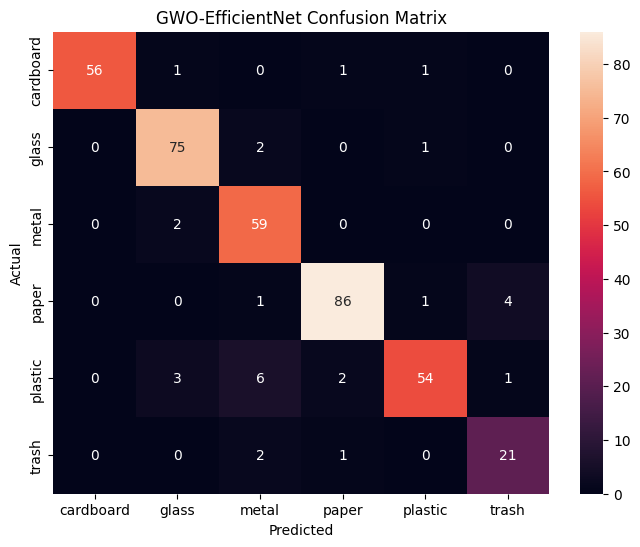

In [28]:
gwo_cm = confusion_matrix(
    gwo_labels,
    gwo_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    gwo_cm,
    annot=True,
    fmt="d",
    xticklabels=base_dataset.classes,
    yticklabels=base_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GWO-EfficientNet Confusion Matrix")

plt.show()

**Baseline vs GWO **

In [29]:
baseline_model = models.efficientnet_b0(
    weights=None
)

num_features = baseline_model.classifier[1].in_features

baseline_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 6)
)

baseline_model = baseline_model.to(device)

baseline_model.load_state_dict(
    torch.load(
        "/kaggle/working/efficientnet_b0_baseline.pth",
        map_location=device
    )
)

baseline_model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [30]:
def evaluate_model(model, loader):

    predictions = []
    labels_all = []

    model.eval()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            predictions.extend(
                preds.cpu().numpy()
            )

            labels_all.extend(
                labels.numpy()
            )

    predictions = np.array(predictions)
    labels_all = np.array(labels_all)

    accuracy = accuracy_score(
        labels_all,
        predictions
    )

    macro_f1 = f1_score(
        labels_all,
        predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        labels_all,
        predictions,
        average="weighted"
    )

    return accuracy, macro_f1, weighted_f1

In [31]:
baseline_accuracy, baseline_macro_f1, baseline_weighted_f1 = evaluate_model(
    baseline_model,
    test_loader
)

print(
    f"Baseline Accuracy : {baseline_accuracy * 100:.2f}%"
)

print(
    f"Baseline Macro F1 : {baseline_macro_f1:.4f}"
)

print(
    f"Baseline Weighted F1 : {baseline_weighted_f1:.4f}"
)

print()

print(
    f"GWO Accuracy      : {gwo_accuracy * 100:.2f}%"
)

print(
    f"GWO Macro F1      : {gwo_macro_f1:.4f}"
)

print(
    f"GWO Weighted F1   : {gwo_weighted_f1:.4f}"
)

Baseline Accuracy : 80.53%
Baseline Macro F1 : 0.7518
Baseline Weighted F1 : 0.7979

GWO Accuracy      : 92.37%
GWO Macro F1      : 0.9135
GWO Weighted F1   : 0.9238


In [32]:
import time

def measure_inference_speed(model, loader, num_batches=50):

    model.eval()

    images, _ = next(iter(loader))
    images = images.to(device)

    for _ in range(10):

        with torch.no_grad():
            _ = model(images)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    total_images = 0

    with torch.no_grad():

        for i, (images, _) in enumerate(loader):

            if i >= num_batches:
                break

            images = images.to(device)

            _ = model(images)

            total_images += images.size(0)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    images_per_second = total_images / elapsed
    milliseconds_per_image = (
        elapsed / total_images
    ) * 1000

    return milliseconds_per_image, images_per_second

In [33]:
baseline_latency, baseline_fps = measure_inference_speed(
    baseline_model,
    test_loader
)

gwo_latency, gwo_fps = measure_inference_speed(
    final_model,
    gwo_test_loader
)

print(
    f"Baseline latency : {baseline_latency:.3f} ms/image"
)

print(
    f"Baseline throughput : {baseline_fps:.2f} images/sec"
)

print()

print(
    f"GWO latency : {gwo_latency:.3f} ms/image"
)

print(
    f"GWO throughput : {gwo_fps:.2f} images/sec"
)

Baseline latency : 3.081 ms/image
Baseline throughput : 324.52 images/sec

GWO latency : 3.100 ms/image
GWO throughput : 322.63 images/sec


 # **Final Result**

EfficientNet without Class and GWO with weigth like more number of image means less weigth given to that class

In [34]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "EfficientNet-B0 Baseline",
        "GWO-EfficientNet-B0"
    ],
    "Accuracy": [
        baseline_accuracy,
        gwo_accuracy
    ],
    "Macro F1": [
        baseline_macro_f1,
        gwo_macro_f1
    ],
    "Weighted F1": [
        baseline_weighted_f1,
        gwo_weighted_f1
    ],
    "Latency (ms/image)": [
        baseline_latency,
        gwo_latency
    ],
    "Throughput (images/sec)": [
        baseline_fps,
        gwo_fps
    ]
})

results

,Model,Accuracy,Macro F1,Weighted F1,Latency (ms/image),Throughput (images/sec)
0,EfficientNet-B0 Baseline,0.805263,0.751804,0.797872,3.081435,324.524151
1,GWO-EfficientNet-B0,0.923684,0.913529,0.923812,3.099501,322.632599


In [35]:
results.to_csv(
    "/kaggle/working/model_comparison.csv",
    index=False
)

print("Results saved to:")
print("/kaggle/working/model_comparison.csv")

Results saved to:
/kaggle/working/model_comparison.csv


In [36]:
from PIL import Image


class_names = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    image_tensor = inference_transform(
        image
    ).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(image_tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predicted_index = torch.argmax(
            probabilities,
            dim=1
        ).item()

    predicted_class = class_names[
        predicted_index
    ]

    confidence = probabilities[
        0,
        predicted_index
    ].item()

    print(
        f"Prediction: {predicted_class}"
    )

    print(
        f"Confidence: {confidence * 100:.2f}%"
    )

    print("\nClass probabilities:")

    for class_name, probability in zip(
        class_names,
        probabilities[0]
    ):
        print(
            f"{class_name:10s}: "
            f"{probability.item() * 100:.2f}%"
        )

    return predicted_class, confidence

In [37]:
from torchvision import transforms

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Inference transform ready")

Inference transform ready


In [38]:
predict_image(
    "/kaggle/input/datasets/priyal1608/trashimg/Trash.jpeg"
)

Prediction: metal
Confidence: 93.76%

Class probabilities:
cardboard : 2.36%
glass     : 1.77%
metal     : 93.76%
paper     : 0.95%
plastic   : 0.83%
trash     : 0.33%


('metal', 0.9375755190849304)

# **Fine-tunning Model**

In [39]:
import os
from collections import Counter

DATA_DIR = "/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized"

class_counts = {}

for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        class_counts[class_name] = count

print("Dataset distribution:\n")

for cls, count in class_counts.items():
    print(f"{cls:10s}: {count}")

Dataset distribution:

cardboard : 403
glass     : 501
metal     : 410
paper     : 594
plastic   : 482
trash     : 137


**Train/Validate/Test Datasets******

In [40]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

DATA_DIR = "/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    transforms.RandomResizedCrop(
        224,
        scale=(0.75, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.25,
        hue=0.05
    ),

    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3
        )
    ], p=0.15),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=mean,
        std=std
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=mean,
        std=std
    )
])


base_dataset = datasets.ImageFolder(
    root=DATA_DIR
)

class_names = base_dataset.classes

print("Classes:", class_names)

total_size = len(base_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset, test_subset = torch.utils.data.random_split(
    base_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

train_dataset_full = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)

eval_dataset_full = datasets.ImageFolder(
    root=DATA_DIR,
    transform=eval_transform
)


train_dataset = Subset(
    train_dataset_full,
    train_subset.indices
)

val_dataset = Subset(
    eval_dataset_full,
    val_subset.indices
)

test_dataset = Subset(
    eval_dataset_full,
    test_subset.indices
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("\nDataset sizes:")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Device: cuda
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Dataset sizes:
Train: 1768
Validation: 379
Test: 380


**Calculating Class Weigth**
As some class has more images than other class

In [41]:

train_labels = [
    base_dataset.targets[i]
    for i in train_subset.indices
]

class_counts = np.bincount(
    train_labels,
    minlength=len(class_names)
)

print("Training class counts:")

for cls, count in zip(class_names, class_counts):
    print(f"{cls:10s}: {count}")

class_weights = len(train_labels) / (
    len(class_names) * class_counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("\nClass weights:")

for cls, weight in zip(class_names, class_weights):
    print(f"{cls:10s}: {weight.item():.4f}")

Training class counts:
cardboard : 290
glass     : 356
metal     : 281
paper     : 419
plastic   : 333
trash     : 89

Class weights:
cardboard : 1.0161
glass     : 0.8277
metal     : 1.0486
paper     : 0.7033
plastic   : 0.8849
trash     : 3.3109


Fine-Tunning last several layers of Efficient-Net  
Using Multi-Layer Classifier 

In [42]:

from torchvision import models

weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(
    weights=weights
)

for param in model.features.parameters():
    param.requires_grad = False

for param in model.features[-4:].parameters():
    param.requires_grad = True

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(

    nn.Dropout(p=0.35),

    nn.Linear(
        num_features,
        256
    ),

    nn.ReLU(),

    nn.BatchNorm1d(256),

    nn.Dropout(p=0.25),

    nn.Linear(
        256,
        6
    )
)


model = model.to(device)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Loss Function

In [43]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

**CosineAnnealingLR Sechduler**  :It is dynamically adjusting optimizer's LR.

In [44]:
optimizer = torch.optim.AdamW(
    [
        {
            "params": model.features[-4:].parameters(),
            "lr": 1e-5
        },

        {
            "params": model.classifier.parameters(),
            "lr": 3e-4
        }
    ],

    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=25,
    eta_min=1e-6
)

print("Optimizer and scheduler created successfully.")

print("Initial classifier LR:",
      optimizer.param_groups[1]["lr"])

print("Initial backbone LR:",
      optimizer.param_groups[0]["lr"])

print("Optimizer:", type(optimizer).__name__)
print("Scheduler:", type(scheduler).__name__)

Optimizer and scheduler created successfully.
Initial classifier LR: 0.0003
Initial backbone LR: 1e-05
Optimizer: AdamW
Scheduler: CosineAnnealingLR


# **Trainning Function** 

In [45]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [46]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

Training improve model containing 25 epoch

In [47]:
import copy
import time

NUM_EPOCHS = 25

best_val_loss = float("inf")
best_model_state = None

train_losses = []
val_losses = []

train_accs = []
val_accs = []

patience = 6
patience_counter = 0


for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    elapsed = time.time() - start_time

    current_lr = optimizer.param_groups[1]["lr"]

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"LR: {current_lr:.2e} | "
        f"Time: {elapsed:.1f}s"
    )
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            best_model_state,
            "/kaggle/working/efficientnet_improved_best.pth"
        )

        print("   ✓ Best model saved")

        patience_counter = 0

    else:

        patience_counter += 1

    if patience_counter >= patience:

        print("\nEarly stopping triggered.")
        break

Epoch [01/25] | Train Loss: 1.4819 | Train Acc: 51.13% | Val Loss: 1.0986 | Val Acc: 72.56% | LR: 2.99e-04 | Time: 13.7s
   ✓ Best model saved
Epoch [02/25] | Train Loss: 1.1418 | Train Acc: 69.91% | Val Loss: 0.9978 | Val Acc: 76.78% | LR: 2.95e-04 | Time: 13.3s
   ✓ Best model saved
Epoch [03/25] | Train Loss: 1.0717 | Train Acc: 73.59% | Val Loss: 0.9523 | Val Acc: 81.79% | LR: 2.90e-04 | Time: 13.3s
   ✓ Best model saved
Epoch [04/25] | Train Loss: 1.0237 | Train Acc: 75.51% | Val Loss: 0.9041 | Val Acc: 82.85% | LR: 2.82e-04 | Time: 13.8s
   ✓ Best model saved
Epoch [05/25] | Train Loss: 0.9863 | Train Acc: 78.34% | Val Loss: 0.8847 | Val Acc: 83.11% | LR: 2.71e-04 | Time: 13.6s
   ✓ Best model saved
Epoch [06/25] | Train Loss: 0.9644 | Train Acc: 78.85% | Val Loss: 0.9087 | Val Acc: 83.11% | LR: 2.59e-04 | Time: 13.3s
Epoch [07/25] | Train Loss: 0.9333 | Train Acc: 81.17% | Val Loss: 0.8733 | Val Acc: 83.91% | LR: 2.46e-04 | Time: 13.3s
   ✓ Best model saved
Epoch [08/25] | Train

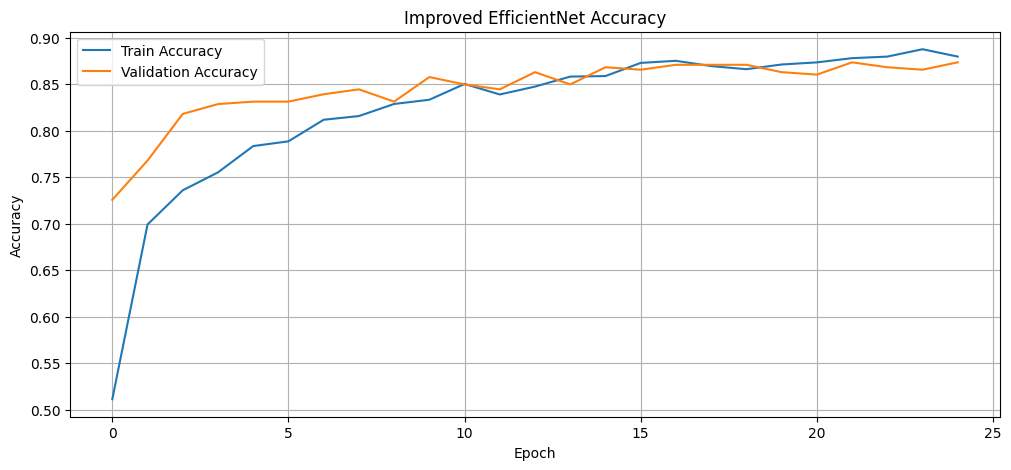

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    train_accs,
    label="Train Accuracy"
)

plt.plot(
    val_accs,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Improved EfficientNet Accuracy"
)

plt.legend()

plt.grid()

plt.show()

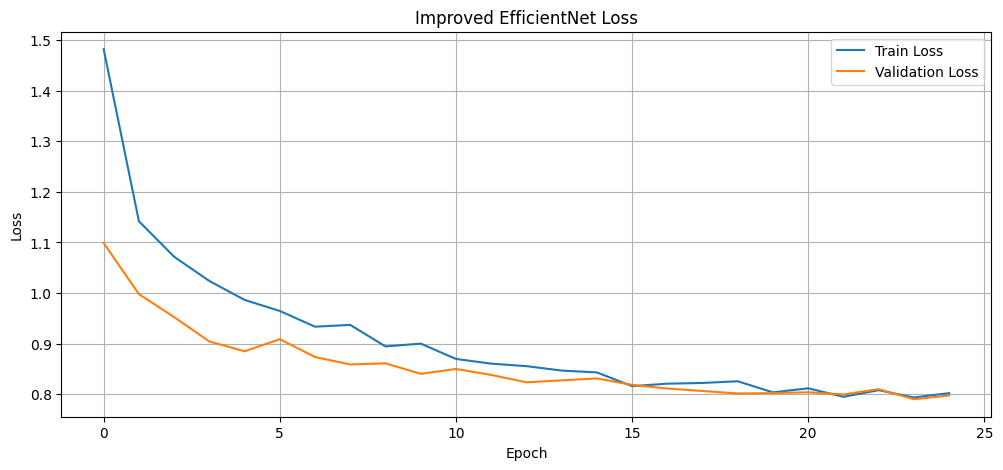

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Improved EfficientNet Loss")

plt.legend()
plt.grid(True)

plt.show()

In [50]:
model.load_state_dict(
    torch.load(
        "/kaggle/working/efficientnet_improved_best.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

print("Best model loaded.")

Best model loaded.


**Evaluting Test Data**

In [51]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import numpy as np


all_predictions = []
all_labels = []


model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = outputs.argmax(
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )


all_predictions = np.array(
    all_predictions
)

all_labels = np.array(
    all_labels
)


accuracy = accuracy_score(
    all_labels,
    all_predictions
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

weighted_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)


print(
    f"Test Accuracy : {accuracy*100:.2f}%"
)

print(
    f"Macro F1      : {macro_f1:.4f}"
)

print(
    f"Weighted F1   : {weighted_f1:.4f}"
)


print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names
    )
)

Test Accuracy : 86.05%
Macro F1      : 0.8391
Weighted F1   : 0.8630

Classification Report:

              precision    recall  f1-score   support

   cardboard       0.98      0.92      0.95        59
       glass       0.90      0.90      0.90        78
       metal       0.76      0.92      0.83        61
       paper       0.94      0.88      0.91        92
     plastic       0.87      0.71      0.78        66
       trash       0.58      0.79      0.67        24

    accuracy                           0.86       380
   macro avg       0.84      0.85      0.84       380
weighted avg       0.87      0.86      0.86       380



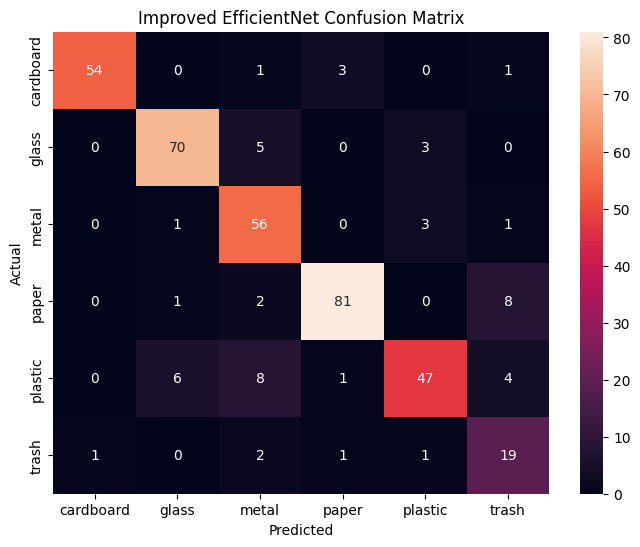

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Improved EfficientNet Confusion Matrix"
)

plt.show()

**Prediction Function ** for testing new img else then Trashnet

In [53]:
from PIL import Image
import torch
from torchvision import transforms

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


def predict_image(
    image_path,
    model,
    device
):

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = (
        inference_transform(image)
        .unsqueeze(0)
        .to(device)
    )


    model.eval()

    with torch.no_grad():

        outputs = model(
            image_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )


    predicted_index = torch.argmax(
        probabilities,
        dim=1
    ).item()

    predicted_class = class_names[
        predicted_index
    ]

    confidence = probabilities[
        0,
        predicted_index
    ].item()


    print(
        "Prediction:",
        predicted_class
    )

    print(
        f"Confidence: "
        f"{confidence*100:.2f}%"
    )


    print("\nClass probabilities:")

    sorted_probs = sorted(
        zip(
            class_names,
            probabilities[0].cpu().numpy()
        ),
        key=lambda x: x[1],
        reverse=True
    )


    for class_name, probability in sorted_probs:

        print(
            f"{class_name:10s}: "
            f"{probability*100:.2f}%"
        )


    return predicted_class, confidence

**Test -Time Augmentation**

In [54]:
tta_transforms = [

    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),

    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),

    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(
            degrees=(5, 5)
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])
]

In [55]:
def predict_tta(
    image_path,
    model,
    device
):

    image = Image.open(
        image_path
    ).convert("RGB")

    all_probabilities = []

    model.eval()

    with torch.no_grad():

        for transform in tta_transforms:

            image_tensor = (
                transform(image)
                .unsqueeze(0)
                .to(device)
            )

            outputs = model(
                image_tensor
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            all_probabilities.append(
                probabilities
            )


    # Average predictions
    mean_probabilities = torch.stack(
        all_probabilities
    ).mean(dim=0)


    predicted_index = torch.argmax(
        mean_probabilities,
        dim=1
    ).item()


    predicted_class = class_names[
        predicted_index
    ]

    confidence = mean_probabilities[
        0,
        predicted_index
    ].item()


    print(
        "TTA Prediction:",
        predicted_class
    )

    print(
        f"TTA Confidence: "
        f"{confidence*100:.2f}%"
    )


    print("\nTTA probabilities:")

    for class_name, probability in zip(
        class_names,
        mean_probabilities[0]
    ):

        print(
            f"{class_name:10s}: "
            f"{probability.item()*100:.2f}%"
        )


    return predicted_class, confidence

# **Testing New Data**

In [56]:
import os
import copy
import time
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


In [57]:
DATA_DIR = "/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized"

print("Dataset exists:", os.path.exists(DATA_DIR))

Dataset exists: True


In [58]:
IMG_SIZE = 224

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.75, 1.0)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [59]:
base_dataset = datasets.ImageFolder(
    DATA_DIR
)

class_names = base_dataset.classes

print("Classes:", class_names)

targets = np.array(base_dataset.targets)

class_indices = {}

for class_id, class_name in enumerate(class_names):

    indices = np.where(
        targets == class_id
    )[0]

    class_indices[class_id] = indices

    print(
        class_name,
        len(indices)
    )

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
cardboard 403
glass 501
metal 410
paper 594
plastic 482
trash 137


Creating equal test set 

In [60]:
TEST_PER_CLASS = 100

In [61]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


train_indices = []
val_indices = []
test_indices = []


for class_id in range(len(class_names)):

    indices = class_indices[class_id].copy()

    np.random.shuffle(indices)

    test_idx = indices[:TEST_PER_CLASS]

    remaining = indices[TEST_PER_CLASS:]

    val_size = int(
        0.15 * len(indices)
    )

    val_idx = remaining[:val_size]

    train_idx = remaining[val_size:]

    test_indices.extend(test_idx)
    val_indices.extend(val_idx)
    train_indices.extend(train_idx)


print("Train:", len(train_indices))
print("Validation:", len(val_indices))
print("Test:", len(test_indices))

Train: 1550
Validation: 377
Test: 600


In [62]:
print("\nBalanced test distribution:")

test_targets = targets[test_indices]

for class_id, class_name in enumerate(class_names):

    count = np.sum(
        test_targets == class_id
    )

    print(
        f"{class_name:10s}: {count}"
    )


Balanced test distribution:
cardboard : 100
glass     : 100
metal     : 100
paper     : 100
plastic   : 100
trash     : 100


In [63]:
BATCH_SIZE = 32

pin = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=pin
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=pin
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=pin
)

print("DataLoaders ready.")

DataLoaders ready.


**EfficientNet Model Functions**

In [64]:
def create_efficientnet(
    dropout=0.3,
    pretrained=True
):

    if pretrained:

        weights = (
            models.EfficientNet_B0_Weights.DEFAULT
        )

    else:

        weights = None


    model = models.efficientnet_b0(
        weights=weights
    )


    for param in model.features.parameters():
        param.requires_grad = False


    for param in model.features[-4:].parameters():
        param.requires_grad = True


    num_features = (
        model.classifier[1].in_features
    )


    model.classifier = nn.Sequential(

        nn.Dropout(dropout),

        nn.Linear(
            num_features,
            256
        ),

        nn.ReLU(),

        nn.BatchNorm1d(256),

        nn.Dropout(dropout),

        nn.Linear(
            256,
            len(class_names)
        )
    )


    return model.to(device)

Training Functions

In [65]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total
    )

Validate function

In [66]:
def evaluate_loader(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() *
                images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

            all_preds.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    loss = running_loss / total
    accuracy = correct / total

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    return (
        loss,
        accuracy,
        macro_f1,
        np.array(all_labels),
        np.array(all_preds)
    )

# EfficientNet with Class weigths

In [67]:
weighted_model = create_efficientnet(
    dropout=0.3,
    pretrained=True
)

weighted_criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

weighted_optimizer = torch.optim.AdamW(
    [
        {
            "params": weighted_model.features[-4:].parameters(),
            "lr": 1e-5
        },
        {
            "params": weighted_model.classifier.parameters(),
            "lr": 3e-4
        }
    ],
    weight_decay=1e-4
)

weighted_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    weighted_optimizer,
    T_max=15,
    eta_min=1e-6
)

**Training with weigths**

In [68]:
WEIGHTED_EPOCHS = 15

best_val_loss = float("inf")
best_weighted_state = None

weighted_history = []

for epoch in range(WEIGHTED_EPOCHS):

    start = time.time()

    train_loss, train_acc = train_one_epoch(
        weighted_model,
        train_loader,
        weighted_criterion,
        weighted_optimizer
    )

    val_loss, val_acc, val_f1, _, _ = evaluate_loader(
        weighted_model,
        val_loader,
        weighted_criterion
    )

    weighted_scheduler.step()

    weighted_history.append([
        epoch + 1,
        train_loss,
        train_acc,
        val_loss,
        val_acc,
        val_f1
    ])

    print(
        f"Epoch {epoch+1:02d}/{WEIGHTED_EPOCHS} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"Val Macro-F1: {val_f1:.4f} | "
        f"Time: {time.time()-start:.1f}s"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_weighted_state = copy.deepcopy(
            weighted_model.state_dict()
        )

        torch.save(
            best_weighted_state,
            "/kaggle/working/efficientnet_class_weighted.pth"
        )

Epoch 01/15 | Train Acc: 52.77% | Val Acc: 72.30% | Val Macro-F1: 0.6995 | Time: 13.2s
Epoch 02/15 | Train Acc: 69.29% | Val Acc: 75.73% | Val Macro-F1: 0.7343 | Time: 13.6s
Epoch 03/15 | Train Acc: 72.74% | Val Acc: 77.31% | Val Macro-F1: 0.7503 | Time: 13.7s
Epoch 04/15 | Train Acc: 77.15% | Val Acc: 80.74% | Val Macro-F1: 0.7866 | Time: 13.5s
Epoch 05/15 | Train Acc: 79.30% | Val Acc: 79.95% | Val Macro-F1: 0.7832 | Time: 13.3s
Epoch 06/15 | Train Acc: 79.64% | Val Acc: 80.47% | Val Macro-F1: 0.7850 | Time: 13.5s
Epoch 07/15 | Train Acc: 82.07% | Val Acc: 82.32% | Val Macro-F1: 0.8029 | Time: 13.1s
Epoch 08/15 | Train Acc: 81.00% | Val Acc: 84.96% | Val Macro-F1: 0.8307 | Time: 13.0s
Epoch 09/15 | Train Acc: 82.24% | Val Acc: 84.43% | Val Macro-F1: 0.8246 | Time: 13.4s
Epoch 10/15 | Train Acc: 82.98% | Val Acc: 85.49% | Val Macro-F1: 0.8367 | Time: 13.5s
Epoch 11/15 | Train Acc: 82.69% | Val Acc: 84.43% | Val Macro-F1: 0.8247 | Time: 13.6s
Epoch 12/15 | Train Acc: 84.22% | Val Acc: 

# GWO without weigths

**Training with GWO**

In [69]:
def evaluate_gwo_candidate(
    params,
    epochs=3
):

    lr = params[0]
    dropout = params[1]
    weight_decay = params[2]


    model = create_efficientnet(
        dropout=dropout,
        pretrained=True
    )


    criterion = nn.CrossEntropyLoss(
        label_smoothing=0.1
    )


    optimizer = torch.optim.AdamW(
        [
            {
                "params": model.features[-4:].parameters(),
                "lr": lr * 0.1
            },
            {
                "params": model.classifier.parameters(),
                "lr": lr
            }
        ],
        weight_decay=weight_decay
    )


    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )


    best_f1 = 0


    for epoch in range(epochs):

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        (
            val_loss,
            val_acc,
            val_f1,
            _,
            _
        ) = evaluate_loader(
            model,
            val_loader,
            criterion
        )

        scheduler.step()

        best_f1 = max(
            best_f1,
            val_f1
        )


    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    return best_f1

Gwo implentation

In [70]:
class GreyWolfOptimizer:

    def __init__(
        self,
        objective,
        bounds,
        num_wolves=5,
        iterations=5
    ):

        self.objective = objective
        self.bounds = np.array(bounds)
        self.num_wolves = num_wolves
        self.iterations = iterations

        self.dim = len(bounds)

        self.positions = np.zeros(
            (num_wolves, self.dim)
        )

        for i in range(num_wolves):

            for j in range(self.dim):

                low = bounds[j][0]
                high = bounds[j][1]

                self.positions[i, j] = np.random.uniform(
                    low,
                    high
                )


    def optimize(self):

        alpha_score = -np.inf
        beta_score = -np.inf
        delta_score = -np.inf

        alpha_pos = np.zeros(self.dim)
        beta_pos = np.zeros(self.dim)
        delta_pos = np.zeros(self.dim)

        history = []


        for iteration in range(self.iterations):

            print(
                f"\nGWO Iteration "
                f"{iteration+1}/{self.iterations}"
            )


            for i in range(self.num_wolves):

                score = self.objective(
                    self.positions[i]
                )

                print(
                    f"Wolf {i+1}: "
                    f"{score:.4f}"
                )


                if score > alpha_score:

                    delta_score = beta_score
                    delta_pos = beta_pos.copy()

                    beta_score = alpha_score
                    beta_pos = alpha_pos.copy()

                    alpha_score = score
                    alpha_pos = self.positions[i].copy()


                elif score > beta_score:

                    delta_score = beta_score
                    delta_pos = beta_pos.copy()

                    beta_score = score
                    beta_pos = self.positions[i].copy()


                elif score > delta_score:

                    delta_score = score
                    delta_pos = self.positions[i].copy()


            a = 2 - iteration * (
                2 / self.iterations
            )


            for i in range(self.num_wolves):

                for j in range(self.dim):

                    r1 = np.random.random()
                    r2 = np.random.random()

                    A1 = 2 * a * r1 - a
                    C1 = 2 * r2

                    D_alpha = abs(
                        C1 * alpha_pos[j]
                        - self.positions[i, j]
                    )

                    X1 = (
                        alpha_pos[j]
                        - A1 * D_alpha
                    )


                    r1 = np.random.random()
                    r2 = np.random.random()

                    A2 = 2 * a * r1 - a
                    C2 = 2 * r2

                    D_beta = abs(
                        C2 * beta_pos[j]
                        - self.positions[i, j]
                    )

                    X2 = (
                        beta_pos[j]
                        - A2 * D_beta
                    )


                    r1 = np.random.random()
                    r2 = np.random.random()

                    A3 = 2 * a * r1 - a
                    C3 = 2 * r2

                    D_delta = abs(
                        C3 * delta_pos[j]
                        - self.positions[i, j]
                    )

                    X3 = (
                        delta_pos[j]
                        - A3 * D_delta
                    )


                    self.positions[i, j] = (
                        X1 + X2 + X3
                    ) / 3


                    low = self.bounds[j][0]
                    high = self.bounds[j][1]

                    self.positions[i, j] = np.clip(
                        self.positions[i, j],
                        low,
                        high
                    )


            history.append({
                "iteration": iteration + 1,
                "alpha_score": alpha_score,
                "alpha_position": alpha_pos.copy()
            })


            print(
                "Alpha Macro-F1:",
                round(alpha_score, 4)
            )

            print(
                "Alpha parameters:",
                alpha_pos
            )


        return (
            alpha_pos,
            alpha_score,
            history
        )

In [71]:
gwo_bounds = [
    (1e-5, 5e-4),
    (0.1, 0.5),
    (1e-6, 1e-3)
]

In [72]:
gwo = GreyWolfOptimizer(  
    objective=lambda params: evaluate_gwo_candidate(
        params,
        epochs=3
    ),
    bounds=gwo_bounds,
    num_wolves=4,
    iterations=3
)

best_params, best_gwo_f1, gwo_history = gwo.optimize()

print("\n==============================")
print("GWO COMPLETE")
print("==============================")

print(
    "Best learning rate:",
    best_params[0]
)

print(
    "Best dropout:",
    best_params[1]
)

print(
    "Best weight decay:",
    best_params[2]
)

print(
    "Best validation Macro-F1:",
    best_gwo_f1
)


GWO Iteration 1/3
Wolf 1: 0.6981
Wolf 2: 0.7589
Wolf 3: 0.7713


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x781dc7bae7a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x781dc7bae7a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Wolf 4: 0.7911
Alpha Macro-F1: 0.7911
Alpha parameters: [4.88235516e-04 3.66940159e-01 1.14172717e-05]

GWO Iteration 2/3
Wolf 1: 0.7821
Wolf 2: 0.7984
Wolf 3: 0.7538
Wolf 4: 0.7846
Alpha Macro-F1: 0.7984
Alpha parameters: [0.0005     0.1        0.00040624]

GWO Iteration 3/3
Wolf 1: 0.8015
Wolf 2: 0.7974
Wolf 3: 0.7936
Wolf 4: 0.7996
Alpha Macro-F1: 0.8015
Alpha parameters: [4.66228248e-04 1.00000000e-01 1.00000000e-06]

GWO COMPLETE
Best learning rate: 0.0004662282475717096
Best dropout: 0.1
Best weight decay: 1e-06
Best validation Macro-F1: 0.8015106374235671


**Train Final GWO**

In [73]:
gwo_lr = best_params[0]
gwo_dropout = best_params[1]
gwo_weight_decay = best_params[2]

In [74]:
gwo_model = create_efficientnet(
    dropout=gwo_dropout,
    pretrained=True
)

**No class weigths**

In [75]:
gwo_criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

Optimizer

In [76]:
gwo_optimizer = torch.optim.AdamW(
    [
        {
            "params": gwo_model.features[-4:].parameters(),
            "lr": gwo_lr * 0.1
        },
        {
            "params": gwo_model.classifier.parameters(),
            "lr": gwo_lr
        }
    ],
    weight_decay=gwo_weight_decay
)

gwo_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    gwo_optimizer,
    T_max=15,
    eta_min=1e-6
)

Train GWO Model

In [77]:
GWO_EPOCHS = 15

best_val_loss = float("inf")
best_gwo_state = None

gwo_history_final = []

for epoch in range(GWO_EPOCHS):

    start = time.time()

    train_loss, train_acc = train_one_epoch(
        gwo_model,
        train_loader,
        gwo_criterion,
        gwo_optimizer
    )

    (
        val_loss,
        val_acc,
        val_f1,
        _,
        _
    ) = evaluate_loader(
        gwo_model,
        val_loader,
        gwo_criterion
    )

    gwo_scheduler.step()

    gwo_history_final.append([
        epoch + 1,
        train_loss,
        train_acc,
        val_loss,
        val_acc,
        val_f1
    ])

    print(
        f"Epoch {epoch+1:02d}/{GWO_EPOCHS} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"Val Macro-F1: {val_f1:.4f} | "
        f"Time: {time.time()-start:.1f}s"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_gwo_state = copy.deepcopy(
            gwo_model.state_dict()
        )

        torch.save(
            best_gwo_state,
            "/kaggle/working/gwo_efficientnet_no_class_weights.pth"
        )

Epoch 01/15 | Train Acc: 64.59% | Val Acc: 82.06% | Val Macro-F1: 0.7913 | Time: 13.4s
Epoch 02/15 | Train Acc: 80.37% | Val Acc: 84.70% | Val Macro-F1: 0.8186 | Time: 13.6s
Epoch 03/15 | Train Acc: 84.56% | Val Acc: 84.17% | Val Macro-F1: 0.8141 | Time: 13.3s
Epoch 04/15 | Train Acc: 87.78% | Val Acc: 86.54% | Val Macro-F1: 0.8388 | Time: 13.4s
Epoch 05/15 | Train Acc: 89.88% | Val Acc: 87.34% | Val Macro-F1: 0.8624 | Time: 13.4s
Epoch 06/15 | Train Acc: 90.89% | Val Acc: 87.34% | Val Macro-F1: 0.8561 | Time: 13.5s
Epoch 07/15 | Train Acc: 92.99% | Val Acc: 88.65% | Val Macro-F1: 0.8706 | Time: 13.6s
Epoch 08/15 | Train Acc: 93.50% | Val Acc: 91.03% | Val Macro-F1: 0.8952 | Time: 13.4s
Epoch 09/15 | Train Acc: 95.81% | Val Acc: 90.24% | Val Macro-F1: 0.8829 | Time: 13.7s
Epoch 10/15 | Train Acc: 95.19% | Val Acc: 91.29% | Val Macro-F1: 0.8954 | Time: 13.3s
Epoch 11/15 | Train Acc: 95.25% | Val Acc: 91.82% | Val Macro-F1: 0.9056 | Time: 13.3s
Epoch 12/15 | Train Acc: 96.10% | Val Acc: 

Load Best Model

In [78]:
weighted_model.load_state_dict(
    torch.load(
        "/kaggle/working/efficientnet_class_weighted.pth",
        map_location=device
    )
)

gwo_model.load_state_dict(
    torch.load(
        "/kaggle/working/gwo_efficientnet_no_class_weights.pth",
        map_location=device
    )
)

weighted_model.eval()
gwo_model.eval()

print("Both best models loaded.")

Both best models loaded.


**Evaluate both model on same test dataset **

In [79]:
def evaluate_test_model(
    model,
    loader
):

    model.eval()

    all_labels = []
    all_predictions = []

    start = time.time()

    total_images = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            predictions = outputs.argmax(
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

            total_images += images.size(0)


    elapsed = time.time() - start

    labels = np.array(all_labels)
    predictions = np.array(all_predictions)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        labels,
        predictions,
        average="weighted"
    )

    latency = (
        elapsed / total_images
    ) * 1000

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "latency_ms": latency,
        "labels": labels,
        "predictions": predictions
    }

Evaluate efficientNet 

In [80]:
weighted_results = evaluate_test_model(
    weighted_model,
    test_loader
)

print("WEIGHTED EFFICIENTNET")

print(
    "Accuracy:",
    weighted_results["accuracy"] * 100
)

print(
    "Macro F1:",
    weighted_results["macro_f1"]
)

print(
    "Weighted F1:",
    weighted_results["weighted_f1"]
)

print(
    "Latency:",
    weighted_results["latency_ms"],
    "ms/image"
)

WEIGHTED EFFICIENTNET
Accuracy: 83.15789473684211
Macro F1: 0.8065737486424921
Weighted F1: 0.8369682773257936
Latency: 4.9019455909729 ms/image


Evaluate GWO

In [81]:
gwo_results = evaluate_test_model(
    gwo_model,
    test_loader
)

print("GWO EFFICIENTNET - NO CLASS WEIGHTS")

print(
    "Accuracy:",
    gwo_results["accuracy"] * 100
)

print(
    "Macro F1:",
    gwo_results["macro_f1"]
)

print(
    "Weighted F1:",
    gwo_results["weighted_f1"]
)

print(
    "Latency:",
    gwo_results["latency_ms"],
    "ms/image"
)

GWO EFFICIENTNET - NO CLASS WEIGHTS
Accuracy: 90.26315789473685
Macro F1: 0.883590464322749
Weighted F1: 0.9020683429807517
Latency: 3.28952011309172 ms/image


# Final comparision between models

Here efficient is with weigth and GWO without weigths .

In [82]:
comparison = pd.DataFrame({
    "Model": [
        "EfficientNet + Class Weights",
        "EfficientNet + GWO"
    ],

    "Accuracy (%)": [
        weighted_results["accuracy"] * 100,
        gwo_results["accuracy"] * 100
    ],

    "Macro F1 (%)": [
        weighted_results["macro_f1"] * 100,
        gwo_results["macro_f1"] * 100
    ],

    "Weighted F1 (%)": [
        weighted_results["weighted_f1"] * 100,
        gwo_results["weighted_f1"] * 100
    ],

    "Inference Latency (ms/image)": [
        weighted_results["latency_ms"],
        gwo_results["latency_ms"]
    ]
})

comparison

,Model,Accuracy (%),Macro F1 (%),Weighted F1 (%),Inference Latency (ms/image)
0,EfficientNet + Class Weights,83.157895,80.657375,83.696828,4.901946
1,EfficientNet + GWO,90.263158,88.359046,90.206834,3.289520


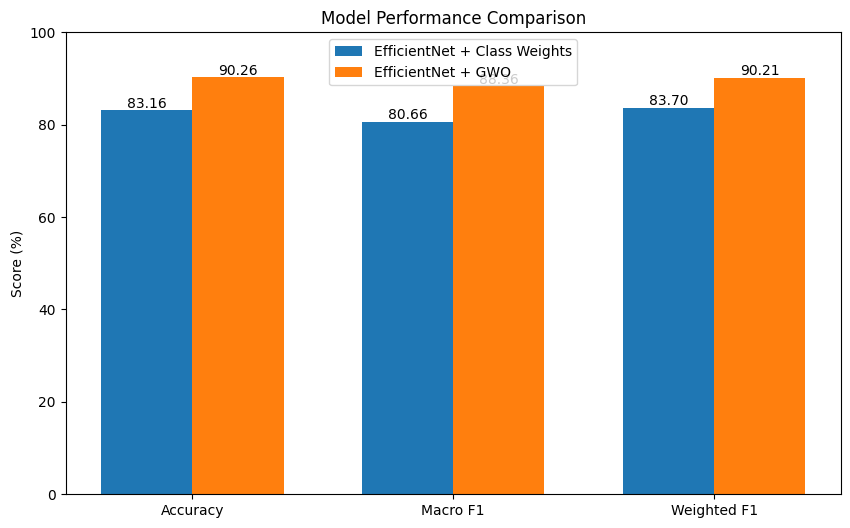

In [83]:
metrics = [
    "Accuracy",
    "Macro F1",
    "Weighted F1"
]

weighted_values = [
    weighted_results["accuracy"] * 100,
    weighted_results["macro_f1"] * 100,
    weighted_results["weighted_f1"] * 100
]

gwo_values = [
    gwo_results["accuracy"] * 100,
    gwo_results["macro_f1"] * 100,
    gwo_results["weighted_f1"] * 100
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    weighted_values,
    width,
    label="EfficientNet + Class Weights"
)

bars2 = plt.bar(
    x + width/2,
    gwo_values,
    width,
    label="EfficientNet + GWO"
)

plt.ylabel("Score (%)")
plt.title("Model Performance Comparison")

plt.xticks(
    x,
    metrics
)

plt.ylim(0, 100)

plt.legend()

for bars in [bars1, bars2]:

    for bar in bars:

        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.2f}",
            ha="center"
        )

plt.show()

# Models with direct-frequency class-weight

In [84]:
import os
import copy
import time
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [85]:
DATA_DIR = "/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized"

dataset_check = datasets.ImageFolder(DATA_DIR)

class_names = dataset_check.classes
targets = np.array(dataset_check.targets)

print("Classes:")
print(class_names)

print("\nTotal images:", len(targets))

Classes:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Total images: 2527


Transform

In [86]:
IMG_SIZE = 224

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.75, 1.0)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

Create Test/train/validate dataset

In [87]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


class_indices = {}

for class_id in range(len(class_names)):

    indices = np.where(
        targets == class_id
    )[0]

    np.random.shuffle(indices)

    class_indices[class_id] = indices


min_class_count = min(
    len(indices)
    for indices in class_indices.values()
)

TEST_PER_CLASS = min(
    100,
    int(min_class_count * 0.15)
)

print(
    "Test images per class:",
    TEST_PER_CLASS
)


train_indices = []
val_indices = []
test_indices = []


for class_id in range(len(class_names)):

    indices = class_indices[class_id]

    test_idx = indices[:TEST_PER_CLASS]

    remaining = indices[TEST_PER_CLASS:]

    val_size = int(
        0.15 * len(remaining)
    )

    val_idx = remaining[:val_size]

    train_idx = remaining[val_size:]

    test_indices.extend(test_idx)
    val_indices.extend(val_idx)
    train_indices.extend(train_idx)


print("Train:", len(train_indices))
print("Validation:", len(val_indices))
print("Test:", len(test_indices))

Test images per class: 20
Train: 2048
Validation: 359
Test: 120


In [88]:
train_targets = targets[train_indices]

class_counts = np.bincount(
    train_targets,
    minlength=len(class_names)
)

print("\nTraining distribution:")

for class_name, count in zip(
    class_names,
    class_counts
):

    print(
        f"{class_name:10s}: {count}"
    )


Training distribution:
cardboard : 326
glass     : 409
metal     : 332
paper     : 488
plastic   : 393
trash     : 100


**Calculating reverse weigths**

In [89]:
class_weights = (
    class_counts /
    class_counts.mean()
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)


print("\nClass weights:")

for class_name, count, weight in zip(
    class_names,
    class_counts,
    class_weights
):

    print(
        f"{class_name:10s} "
        f"images={count:5d} "
        f"weight={weight.item():.4f}"
    )


Class weights:
cardboard  images=  326 weight=0.9551
glass      images=  409 weight=1.1982
metal      images=  332 weight=0.9727
paper      images=  488 weight=1.4297
plastic    images=  393 weight=1.1514
trash      images=  100 weight=0.2930


In [90]:
train_dataset_full = datasets.ImageFolder(
    DATA_DIR,
    transform=train_transform
)

eval_dataset_full = datasets.ImageFolder(
    DATA_DIR,
    transform=test_transform
)

train_dataset = Subset(
    train_dataset_full,
    train_indices
)

val_dataset = Subset(
    eval_dataset_full,
    val_indices
)

test_dataset = Subset(
    eval_dataset_full,
    test_indices
)

In [91]:
BATCH_SIZE = 32

pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=pin_memory
)

print("DataLoaders created.")

DataLoaders created.


**EfficientNet  Model**

In [92]:
def create_efficientnet(dropout=0.3):

    weights = models.EfficientNet_B0_Weights.DEFAULT

    model = models.efficientnet_b0(
        weights=weights
    )

    for param in model.features.parameters():
        param.requires_grad = False

    for param in model.features[-4:].parameters():
        param.requires_grad = True

    num_features = (
        model.classifier[1].in_features
    )

    model.classifier = nn.Sequential(
        nn.Dropout(dropout),

        nn.Linear(
            num_features,
            256
        ),

        nn.ReLU(),

        nn.BatchNorm1d(256),

        nn.Dropout(dropout),

        nn.Linear(
            256,
            len(class_names)
        )
    )

    return model.to(device)

Training Function

In [93]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        total_loss / total,
        correct / total
    )

Validate Fiunction

In [94]:
def evaluate_model(
    model,
    loader,
    criterion
):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += (
                loss.item() *
                images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    loss = total_loss / total

    accuracy = correct / total

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return (
        loss,
        accuracy,
        macro_f1,
        np.array(all_labels),
        np.array(all_predictions)
    )

GWO Objective function : it will optimize LR , Dropout , Weigth Decay

In [95]:
def gwo_objective(
    params,
    epochs=3
):

    lr = params[0]
    dropout = params[1]
    weight_decay = params[2]

    model = create_efficientnet(
        dropout=dropout
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=0.1
    )

    optimizer = torch.optim.AdamW(
        [
            {
                "params": model.features[-4:].parameters(),
                "lr": lr * 0.1
            },
            {
                "params": model.classifier.parameters(),
                "lr": lr
            }
        ],
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    best_f1 = 0

    for epoch in range(epochs):

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        (
            val_loss,
            val_acc,
            val_f1,
            _,
            _
        ) = evaluate_model(
            model,
            val_loader,
            criterion
        )

        scheduler.step()

        best_f1 = max(
            best_f1,
            val_f1
        )

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_f1

GWO implementation

In [96]:
import numpy as np


class GWO:

    def __init__(
        self, objective, bounds, n_wolves=4, n_iterations=3
    ):

        self.objective = objective
        self.bounds = np.array(bounds)

        self.n_wolves = n_wolves
        self.n_iterations = n_iterations

        self.dim = len(bounds)

        self.positions = np.zeros((n_wolves, self.dim))

        for i in range(n_wolves):
            for j in range(self.dim):
                self.positions[i, j] = np.random.uniform(
                    bounds[j][0], bounds[j][1]
                )

    def optimize(self):

        alpha_score = -np.inf
        beta_score = -np.inf
        delta_score = -np.inf

        alpha_pos = None
        beta_pos = None
        delta_pos = None

        history = []

        for iteration in range(self.n_iterations):

            print(
                f"\nGWO Iteration "
                f"{iteration + 1}/"
                f"{self.n_iterations}"
            )

            for i in range(self.n_wolves):

                score = self.objective(self.positions[i])

                print(
                    f"Wolf {i+1} "
                    f"Macro-F1 = "
                    f"{score:.4f}"
                )

                if score > alpha_score:

                    delta_score = beta_score
                    delta_pos = (
                        None
                        if beta_pos is None
                        else beta_pos.copy()
                    )

                    beta_score = alpha_score
                    beta_pos = (
                        None
                        if alpha_pos is None
                        else alpha_pos.copy()
                    )

                    alpha_score = score
                    alpha_pos = self.positions[i].copy()

                elif score > beta_score:

                    delta_score = beta_score
                    delta_pos = (
                        None
                        if beta_pos is None
                        else beta_pos.copy()
                    )

                    beta_score = score
                    beta_pos = self.positions[i].copy()

                elif score > delta_score:

                    delta_score = score
                    delta_pos = self.positions[i].copy()

            if (
                alpha_pos is None
                or beta_pos is None
                or delta_pos is None
            ):
                continue

            a = 2 - (
                2 * iteration / self.n_iterations
            )

            for i in range(self.n_wolves):

                for j in range(self.dim):

                    r1 = np.random.rand()
                    r2 = np.random.rand()

                    A1 = 2 * a * r1 - a
                    C1 = 2 * r2

                    D_alpha = abs(
                        C1 * alpha_pos[j]
                        - self.positions[i, j]
                    )

                    X1 = alpha_pos[j] - A1 * D_alpha

                    r1 = np.random.rand()
                    r2 = np.random.rand()

                    A2 = 2 * a * r1 - a
                    C2 = 2 * r2

                    D_beta = abs(
                        C2 * beta_pos[j]
                        - self.positions[i, j]
                    )

                    X2 = beta_pos[j] - A2 * D_beta

                    r1 = np.random.rand()
                    r2 = np.random.rand()

                    A3 = 2 * a * r1 - a
                    C3 = 2 * r2

                    D_delta = abs(
                        C3 * delta_pos[j]
                        - self.positions[i, j]
                    )

                    X3 = delta_pos[j] - A3 * D_delta

                    new_position = (X1 + X2 + X3) / 3

                    low = self.bounds[j][0]
                    high = self.bounds[j][1]

                    self.positions[i, j] = np.clip(
                        new_position, low, high
                    )

            history.append(
                {
                    "iteration": iteration + 1,
                    "alpha_score": alpha_score,
                    "alpha_position": alpha_pos.copy(),
                }
            )

            print(
                "Alpha Macro-F1:",
                round(alpha_score, 4),
            )
        return alpha_pos, alpha_score, history

In [97]:
gwo_bounds = [
    (1e-5, 5e-4),
    (0.1, 0.5),
    (1e-6, 1e-3)
]

In [98]:
gwo = GWO(
    objective=lambda params:
        gwo_objective(
            params,
            epochs=3
        ),
    bounds=gwo_bounds,
    n_wolves=4,
    n_iterations=3
)

best_params, best_score, gwo_history = (
    gwo.optimize()
)

print("BEST GWO PARAMETERS")


print(
    "Learning rate:",
    best_params[0]
)

print(
    "Dropout:",
    best_params[1]
)

print(
    "Weight decay:",
    best_params[2]
)

print(
    "Validation Macro-F1:",
    best_score
)


GWO Iteration 1/3
Wolf 1 Macro-F1 = 0.6828
Wolf 2 Macro-F1 = 0.6900
Wolf 3 Macro-F1 = 0.7033
Wolf 4 Macro-F1 = 0.7123
Alpha Macro-F1: 0.7123

GWO Iteration 2/3
Wolf 1 Macro-F1 = 0.7176
Wolf 2 Macro-F1 = 0.7386
Wolf 3 Macro-F1 = 0.7082
Wolf 4 Macro-F1 = 0.7019
Alpha Macro-F1: 0.7386

GWO Iteration 3/3
Wolf 1 Macro-F1 = 0.7167
Wolf 2 Macro-F1 = 0.6980
Wolf 3 Macro-F1 = 0.6989
Wolf 4 Macro-F1 = 0.7123
Alpha Macro-F1: 0.7386
BEST GWO PARAMETERS
Learning rate: 0.0005
Dropout: 0.1
Weight decay: 0.00040623847043909996
Validation Macro-F1: 0.7386424140109736


Train final model

In [99]:
EPOCHS = 15

best_val_loss = float("inf")
best_model_state = None

history = []

for epoch in range(EPOCHS):

    start = time.time()

    train_loss, train_acc = train_one_epoch(
        gwo_model,
        train_loader,
        gwo_criterion,
        gwo_optimizer
    )

    (
        val_loss,
        val_acc,
        val_f1,
        _,
        _
    ) = evaluate_model(
        gwo_model,
        val_loader,
        gwo_criterion
    )

    gwo_scheduler.step()

    history.append([
        epoch + 1,
        train_loss,
        train_acc,
        val_loss,
        val_acc,
        val_f1
    ])

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"Val Macro-F1: {val_f1:.4f} | "
        f"Time: {time.time()-start:.1f}s"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            gwo_model.state_dict()
        )

        torch.save(
            best_model_state,
            "/kaggle/working/EfficientNet_GWO_ClassWeighted.pth"
        )

Epoch 01/15 | Train Acc: 93.55% | Val Acc: 98.33% | Val Macro-F1: 0.9740 | Time: 15.2s
Epoch 02/15 | Train Acc: 93.60% | Val Acc: 97.77% | Val Macro-F1: 0.9686 | Time: 14.7s
Epoch 03/15 | Train Acc: 93.07% | Val Acc: 98.33% | Val Macro-F1: 0.9777 | Time: 14.6s
Epoch 04/15 | Train Acc: 93.21% | Val Acc: 98.05% | Val Macro-F1: 0.9704 | Time: 14.3s
Epoch 05/15 | Train Acc: 93.55% | Val Acc: 98.05% | Val Macro-F1: 0.9712 | Time: 14.4s
Epoch 06/15 | Train Acc: 94.53% | Val Acc: 97.49% | Val Macro-F1: 0.9659 | Time: 14.7s
Epoch 07/15 | Train Acc: 95.07% | Val Acc: 97.21% | Val Macro-F1: 0.9635 | Time: 15.2s
Epoch 08/15 | Train Acc: 95.31% | Val Acc: 97.77% | Val Macro-F1: 0.9715 | Time: 15.0s
Epoch 09/15 | Train Acc: 95.21% | Val Acc: 96.38% | Val Macro-F1: 0.9512 | Time: 15.2s
Epoch 10/15 | Train Acc: 96.34% | Val Acc: 96.94% | Val Macro-F1: 0.9647 | Time: 15.3s
Epoch 11/15 | Train Acc: 95.95% | Val Acc: 97.21% | Val Macro-F1: 0.9744 | Time: 15.1s
Epoch 12/15 | Train Acc: 97.02% | Val Acc: 

In [100]:
gwo_model.load_state_dict(
    torch.load(
        "/kaggle/working/EfficientNet_GWO_ClassWeighted.pth",
        map_location=device
    )
)

gwo_model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [101]:
test_loss, test_accuracy, test_f1, y_true, y_pred = (
    evaluate_model(
        gwo_model,
        test_loader,
        gwo_criterion
    )
)

print("FINAL TEST RESULTS")


print(
    f"Accuracy : {test_accuracy * 100:.2f}%"
)

print(
    f"Macro F1 : {test_f1:.4f}"
)

FINAL TEST RESULTS
Accuracy : 98.33%
Macro F1 : 0.9833


**Evalutating both models**

In [102]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def get_predictions(model, loader, device):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            all_labels.extend(
                labels.numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    return (
        np.array(all_labels),
        np.array(all_predictions)
    )

In [103]:
weighted_y_true, weighted_y_pred = get_predictions(
    weighted_model,
    test_loader,
    device
)

gwo_y_true, gwo_y_pred = get_predictions(
    gwo_model,
    test_loader,
    device
)

In [104]:
print(
    "Same test labels:",
    np.array_equal(
        weighted_y_true,
        gwo_y_true
    )
)

Same test labels: True


In [105]:
weighted_accuracy = accuracy_score(
    weighted_y_true,
    weighted_y_pred
)

weighted_macro_f1 = f1_score(
    weighted_y_true,
    weighted_y_pred,
    average="macro"
)

weighted_weighted_f1 = f1_score(
    weighted_y_true,
    weighted_y_pred,
    average="weighted"
)


gwo_accuracy = accuracy_score(
    gwo_y_true,
    gwo_y_pred
)

gwo_macro_f1 = f1_score(
    gwo_y_true,
    gwo_y_pred,
    average="macro"
)

gwo_weighted_f1 = f1_score(
    gwo_y_true,
    gwo_y_pred,
    average="weighted"
)

# Final Result 

Both Models has weigths like : more number of images means more weigth to that class

In [106]:
comparison = pd.DataFrame({

    "Model": [
        "EfficientNet + Class Weights",
        "EfficientNet + GWO + Class Weights"
    ],

    "Accuracy (%)": [
        weighted_accuracy * 100,
        gwo_accuracy * 100
    ],

    "Macro F1 (%)": [
        weighted_macro_f1 * 100,
        gwo_macro_f1 * 100
    ],

    "Weighted F1 (%)": [
        weighted_weighted_f1 * 100,
        gwo_weighted_f1 * 100
    ]
})

comparison

,Model,Accuracy (%),Macro F1 (%),Weighted F1 (%)
0,EfficientNet + Class Weights,95.000000,95.007121,95.007121
1,EfficientNet + GWO + Class Weights,98.333333,98.332291,98.332291
